In [ ]:
import time
import math

nodes = 0

def is_winner(b, p):
    wins = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
    return any(all(b[i] == p for i in combo) for combo in wins)

def minimax(b, depth, is_max):
    global nodes
    nodes += 1
    if is_winner(b, "O"): return 1
    if is_winner(b, "X"): return -1
    if " " not in b: return 0

    if is_max:
        best = -math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "O"
                score = minimax(b, depth + 1, False)
                b[i] = " "
                best = max(best, score)
        return best
    else:
        best = math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "X"
                score = minimax(b, depth + 1, True)
                b[i] = " "
                best = min(best, score)
        return best

def play_minimax():
    global nodes
    board = [" " for _ in range(9)]
    print("--- INICIANDO JOGO: MODO MINIMAX PURO ---")

    while True:

        print(f"\n{board[0]}|{board[1]}|{board[2]}\n{board[3]}|{board[4]}|{board[5]}\n{board[6]}|{board[7]}|{board[8]}")
        move = int(input("Sua vez (X) 0-8: "))
        board[move] = "X"

        if is_winner(board, "X") or " " not in board: break


        nodes = 0
        start = time.time()
        best_score = -math.inf
        ai_move = -1

        for i in range(9):
            if board[i] == " ":
                board[i] = "O"
                score = minimax(board, 0, False)
                board[i] = " "
                print(f"Posição {i} avaliada. Score: {score}")
                if score > best_score:
                    best_score = score
                    ai_move = i

        end = time.time()
        board[ai_move] = "O"
        print(f"\nIA JOGOU EM {ai_move}")
        print(f"TEMPO: {end - start:.4f}s | NÓS: {nodes}")

        if is_winner(board, "O") or " " not in board: break

play_minimax()

--- INICIANDO JOGO: MODO MINIMAX PURO ---

 | | 
 | | 
 | | 
Sua vez (X) 0-8: 3
Posição 0 avaliada. Score: 0
Posição 1 avaliada. Score: -1
Posição 2 avaliada. Score: -1
Posição 4 avaliada. Score: 0
Posição 5 avaliada. Score: 0
Posição 6 avaliada. Score: 0
Posição 7 avaliada. Score: -1
Posição 8 avaliada. Score: -1

IA JOGOU EM 0
TEMPO: 0.5279s | NÓS: 63904

O| | 
X| | 
 | | 
Sua vez (X) 0-8: 2
Posição 1 avaliada. Score: -1
Posição 4 avaliada. Score: 0
Posição 5 avaliada. Score: 0
Posição 6 avaliada. Score: -1
Posição 7 avaliada. Score: -1
Posição 8 avaliada. Score: -1

IA JOGOU EM 4
TEMPO: 0.0130s | NÓS: 1404

O| |X
X|O| 
 | | 
Sua vez (X) 0-8: 8
Posição 1 avaliada. Score: -1
Posição 5 avaliada. Score: 0
Posição 6 avaliada. Score: -1
Posição 7 avaliada. Score: -1

IA JOGOU EM 5
TEMPO: 0.0007s | NÓS: 50

O| |X
X|O|O
 | |X
Sua vez (X) 0-8: 6
Posição 1 avaliada. Score: -1
Posição 7 avaliada. Score: 0

IA JOGOU EM 7
TEMPO: 0.0001s | NÓS: 4

O| |X
X|O|O
X|O|X
Sua vez (X) 0-8: 1


In [ ]:
import time
import math

nodes = 0
cutoffs = 0

def is_winner(b, p):
    wins = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
    return any(all(b[i] == p for i in combo) for combo in wins)

def alpha_beta(b, depth, alpha, beta, is_max):
    global nodes, cutoffs
    nodes += 1
    if is_winner(b, "O"): return 1
    if is_winner(b, "X"): return -1
    if " " not in b: return 0

    if is_max:
        best = -math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "O"
                score = alpha_beta(b, depth+1, alpha, beta, False)
                b[i] = " "
                best = max(best, score)
                alpha = max(alpha, best)
                if beta <= alpha:
                    cutoffs += 1
                    break
        return best
    else:
        best = math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "X"
                score = alpha_beta(b, depth+1, alpha, beta, True)
                b[i] = " "
                best = min(best, score)
                beta = min(beta, best)
                if beta <= alpha:
                    cutoffs += 1
                    break
        return best

def play_alphabeta():
    global nodes, cutoffs
    board = [" " for _ in range(9)]
    print("\n--- INICIANDO JOGO: MODO ALPHA-BETA PRUNING ---")

    while True:
        print(f"\n{board[0]}|{board[1]}|{board[2]}\n{board[3]}|{board[4]}|{board[5]}\n{board[6]}|{board[7]}|{board[8]}")
        move = int(input("Sua vez (X) 0-8: "))
        board[move] = "X"

        if is_winner(board, "X") or " " not in board: break

        nodes = 0
        cutoffs = 0
        start = time.time()
        best_score = -math.inf
        ai_move = -1

        for i in range(9):
            if board[i] == " ":
                board[i] = "O"
                score = alpha_beta(board, 0, -math.inf, math.inf, False)
                board[i] = " "
                print(f"Posição {i} avaliada. Score: {score}")
                if score > best_score:
                    best_score = score
                    ai_move = i

        end = time.time()
        board[ai_move] = "O"
        print(f"\nIA JOGOU EM {ai_move}")
        print(f"TEMPO: {end - start:.4f}s | NÓS: {nodes} | PODAS: {cutoffs}")

        if is_winner(board, "O") or " " not in board: break

play_alphabeta()


--- INICIANDO JOGO: MODO ALPHA-BETA PRUNING ---

 | | 
 | | 
 | | 
Sua vez (X) 0-8: 0
Posição 1 avaliada. Score: -1
Posição 2 avaliada. Score: -1
Posição 3 avaliada. Score: -1
Posição 4 avaliada. Score: 0
Posição 5 avaliada. Score: -1
Posição 6 avaliada. Score: -1
Posição 7 avaliada. Score: -1
Posição 8 avaliada. Score: -1

IA JOGOU EM 4
TEMPO: 0.0436s | NÓS: 4089 | PODAS: 1547

X| | 
 |O| 
 | | 
Sua vez (X) 0-8: 1
Posição 2 avaliada. Score: 0
Posição 3 avaliada. Score: -1
Posição 5 avaliada. Score: -1
Posição 6 avaliada. Score: -1
Posição 7 avaliada. Score: -1
Posição 8 avaliada. Score: -1

IA JOGOU EM 2
TEMPO: 0.0022s | NÓS: 220 | PODAS: 86

X|X|O
 |O| 
 | | 
Sua vez (X) 0-8: 6
Posição 3 avaliada. Score: 0
Posição 5 avaliada. Score: -1
Posição 7 avaliada. Score: -1
Posição 8 avaliada. Score: -1

IA JOGOU EM 3
TEMPO: 0.0005s | NÓS: 32 | PODAS: 9

X|X|O
O|O| 
X| | 
Sua vez (X) 0-8: 5
Posição 7 avaliada. Score: 0
Posição 8 avaliada. Score: 0

IA JOGOU EM 7
TEMPO: 0.0001s | NÓS: 4 | POD

Exibindo gráficos comparativos...


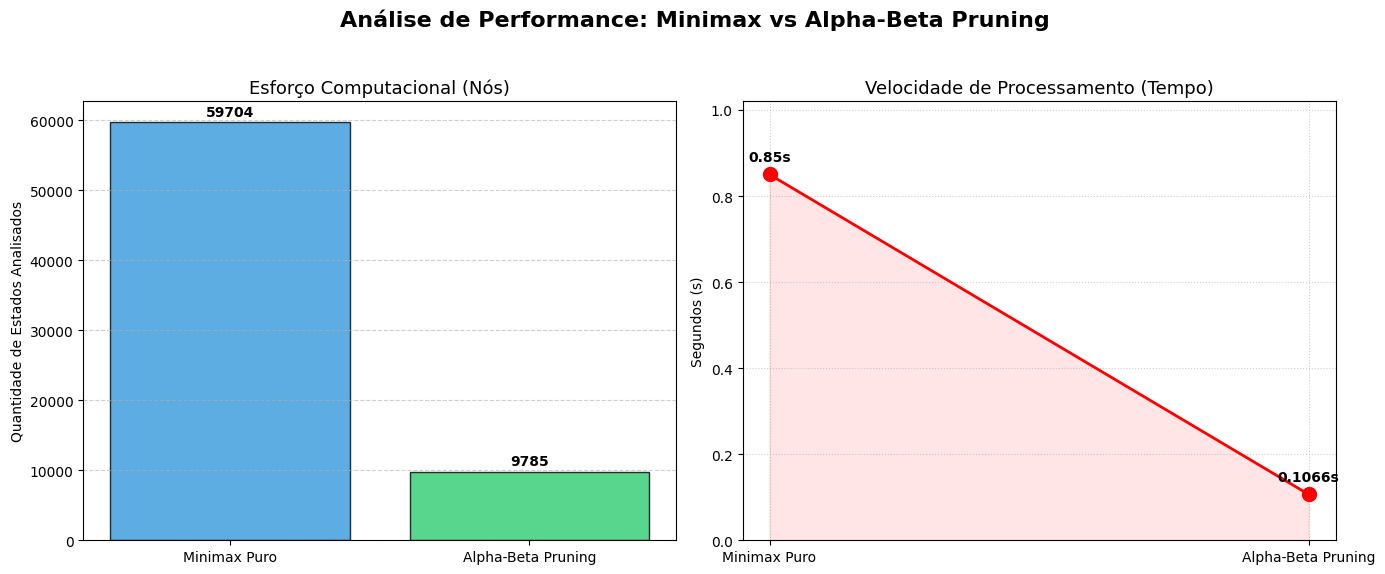

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def gerar_graficos_comparativos():

    labels = ['Minimax Puro', 'Alpha-Beta Pruning']

    nos_visitados = [59704, 9785]

    tempos_execucao = [0.8500, 0.1066]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Análise de Performance: Minimax vs Alpha-Beta Pruning', fontsize=16, fontweight='bold')

    cores_nos = ['#3498db', '#2ecc71']
    barras = ax1.bar(labels, nos_visitados, color=cores_nos, edgecolor='black', alpha=0.8)
    ax1.set_title('Esforço Computacional (Nós)', fontsize=13)
    ax1.set_ylabel('Quantidade de Estados Analisados')
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    for bar in barras:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

    ax2.plot(labels, tempos_execucao, marker='o', linestyle='-', color='red', markersize=10, linewidth=2)
    ax2.fill_between(labels, tempos_execucao, color='red', alpha=0.1)
    ax2.set_title('Velocidade de Processamento (Tempo)', fontsize=13)
    ax2.set_ylabel('Segundos (s)')
    ax2.set_ylim(0, max(tempos_execucao) * 1.2)
    ax2.grid(True, linestyle=':', alpha=0.6)

    for i, txt in enumerate(tempos_execucao):
        ax2.annotate(f'{txt}s', (labels[i], tempos_execucao[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    print("Exibindo gráficos comparativos...")
    plt.show()

if __name__ == "__main__":

    gerar_graficos_comparativos()